<a href="https://colab.research.google.com/github/AxisAngeles/Smart_Data_DS_AI/blob/main/Ejercicios_para_examen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creando un DataFrame de práctica con Numpy

# Preguntas

0.  **Data Generation**: Create a Pandas DataFrame named `df_exam` with fictional data including columns for 'City', 'Country', 'Region', 'Population', and 'Surface Area'.
1.  **Question 1 (Basic Exploration and Filtering)**:
    *   Display the first 5 rows of `df_exam`.
    *   Filter and display cities located in 'South America' with a 'Population' greater than 10,000,000.
2.  **Question 2 (New Column Creation and Sorting)**:
    *   Calculate a new column 'Population_Density' (Population / Surface Area) and add it to `df_exam`.
    *   Sort `df_exam` by 'Population_Density' in descending order and display the result.
3.  **Question 3 (Grouping and Aggregation)**:
    *   Group `df_exam` by 'Region' and calculate the total 'Population' for each region.
    *   Group `df_exam` by 'Country' and find the average 'Surface Area' for each country.
4.  **Question 4 (Row/Column Manipulation and Update)**:
    *   Remove the 'Population_Density' column from `df_exam`.
    *   Add a new city 'Lima', 'Peru', 'South America', with a population of 10,500,000 and a surface area of 3500 to `df_exam`.
    *   Update the 'Population' of 'Mexico City' to 22,000,000 in `df_exam`.
5.  **Question 5 (Data Visualization)**:
    *   Create a bar chart showing the 'Population' of the top 5 cities (by population).
    *   Create a pie chart showing the 'Surface Area' distribution by 'Country'.

Provide the Python code solutions for each question.

## Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from statistics import NormalDist

np.random.seed(2824)

In [62]:
# 1) Elegir número de muestras
# n = int(input('Tamaño de la muestra: '))
n = 5

# 2) Crear columnas con valores aleatorios con Numpy

# 2.1) np.random.choice()     Selecciona entre una lista de variables con base en probabilidades dadas
cities = np.random.choice(['CDMX','GDL','MTY','NY','TX'], size=n, p=[0.40, 0.25, 0.05, 0.20, 0.10])

# 2.2) np.random.randint()    Crea valores enteros entre un rango dado
poblacion = np.random.randint(5000000,20000000,n)

# 2.3) np.random.randint()    Crea valores aleatorios con base en logaritmos normales.
superficie = np.random.lognormal(mean=1.0, sigma=0.45, size=n)
superficie = np.clip(superficie, 1, 5.5) # limita valores a un valor mínimo y uno máximo.

# 2.4) Otras opciones para números aleatorios
beta = superficie * np.random.beta(a=2.0, b=6.0, size=n)
pois = np.random.poisson(lam=1.2, size=n)


# 3) Transforma los arrays en DataFrame
df_exam = pd.DataFrame({
    'City': cities,
    'Population': poblacion,
    'Surface Area': superficie,
    'Beta': beta,
    'Pois': pois
})


# 4) Crear funciones para agrupar países y regiones con base en la ciudad

def selectpais(ciudad):
  if ciudad in ['CDMX','GDL','MTY']:
    return 'MX'
  elif ciudad in ['NY','TX']:
    return 'EU'
  else:
    return 'NA'

def selectregion(ciudad):
  if ciudad in ['CDMX']:
    return 'Centro'
  elif ciudad in ['GDL','MTY']:
    return 'Int_MX'
  elif ciudad in ['NY','TX']:
    return 'Norte'
  else:
    return 'NA'


# 5) Crear columnas con base en las funciones anteriores

df_exam['Country'] = df_exam.apply(lambda x: selectpais(x['City']), axis=1)
df_exam['Region'] = df_exam.apply(lambda x: selectregion(x['City']), axis=1)

# 6) Seleccionar columnas específcias
df_exam = df_exam[['City','Region','Country','Population','Surface Area']]
# df_exam.head()



# 7) ALTERNATIVA: Crear un Dataframe directamente
df_exam = pd.DataFrame(
    {
        'City': ['CDMX','GDL','MTY','NY','TX','Lima','Rio','Buenos Aires','Pekin'],
        'Region': ['MX_Centro','MX_Pacifico','MX_Norte','N_America','N_America','South America','South America','South America','Asia'],
        'Country': ['Mexico','Mexico','Mexico','EEUU','EEUU','Peru','Brasil','Argentina','China'],
        'Population': np.random.randint(5000000,20000000,9),
        'Surface Area(km2)': np.random.lognormal(mean=1.0, sigma=0.45, size=9),
    }
)

# 8) Cambiar el tipo de variable a "texto"
df_exam['City'] = df_exam['City'].astype('string')
df_exam['Region'] = df_exam['Region'].astype('string')
df_exam['Country'] = df_exam['Country'].astype('string')

df_exam

,City,Region,Country,Population,Surface Area(km2)
0,CDMX,MX_Centro,Mexico,18427603,2.026814
1,GDL,MX_Pacifico,Mexico,5696479,2.931681
2,MTY,MX_Norte,Mexico,8865732,2.482314
3,NY,N_America,EEUU,5427111,5.098382
4,TX,N_America,EEUU,19842196,1.677212
5,Lima,South America,Peru,10471131,3.050485
6,Rio,South America,Brasil,5511434,3.626777
7,Buenos Aires,South America,Argentina,16202914,1.420915
8,Pekin,Asia,China,14474653,1.641891


In [135]:
# 1) Preguntas de Examen:

print("Display the first 5 rows of df_exam.")
display(df_exam.head())

print("\n\nFilter and display cities located in 'South America' with a 'Population' greater than 10,000,000.")
display(df_exam.loc[(df_exam['Region'] == 'South America') & (df_exam['Population'] >= 10000000)])

print("\n\nCalculate a new column 'Population_Density' (Population / Surface Area) and add it to df_exam.")
df_exam['Population_Density'] = np.round((df_exam['Population']/df_exam['Surface Area(km2)']),2)
display(df_exam['Population_Density'])

print("\n\nSort df_exam by 'Population_Density' in descending order and display the result.")
display(df_exam.sort_values(['Population_Density'], ascending=False))


print("\n\nGroup df_exam by 'Region' and calculate the total 'Population' for each region.")
display(df_exam[['Region','Population']].groupby('Region').sum().sort_values(['Population'], ascending=False))

print("\n\nGroup df_exam by 'Country' and find the average 'Surface Area' for each country.")
display(df_exam[['Country','Surface Area(km2)']].groupby('Country').agg(['count','mean','sum']))

print("\n\nRemove the 'Population_Density' column from df_exam.")
df_exam = df_exam.drop('Population_Density', axis=1)
display(df_exam)

print("\n\nAdd a new city 'Lima', 'Peru', 'South America', with a population of 10,500,000 and a surface area of 3500 to df_exam.")
df_exam.loc[9] = ['Lima2', 'South America', 'Peru', 10500000,3.500]
display(df_exam)

print("\n\nUpdate the 'Population' of 'Mexico City' to 22,000,000 in df_exam.")
var = df_exam.loc[df_exam['City'] == 'CDMX'].index
df_exam.at[0,'Population'] = 22000000
df_exam.loc[var[0]]


Display the first 5 rows of df_exam.


,City,Region,Country,Population,Surface Area(km2)
0,CDMX,MX_Centro,Mexico,18427603,2.026814
1,GDL,MX_Pacifico,Mexico,5696479,2.931681
2,MTY,MX_Norte,Mexico,8865732,2.482314
3,NY,N_America,EEUU,5427111,5.098382
4,TX,N_America,EEUU,19842196,1.677212




Filter and display cities located in 'South America' with a 'Population' greater than 10,000,000.


,City,Region,Country,Population,Surface Area(km2)
5,Lima,South America,Peru,10471131,3.050485
7,Buenos Aires,South America,Argentina,16202914,1.420915
9,Lima2,South America,Peru,10500000,3.500000




Calculate a new column 'Population_Density' (Population / Surface Area) and add it to df_exam.


...

,City,Region,Country,Population,Surface Area(km2)
0,CDMX,MX_Centro,Mexico,18427603,2.026814
1,GDL,MX_Pacifico,Mexico,5696479,2.931681
2,MTY,MX_Norte,Mexico,8865732,2.482314
3,NY,N_America,EEUU,5427111,5.098382
4,TX,N_America,EEUU,19842196,1.677212
5,Lima,South America,Peru,10471131,3.050485
6,Rio,South America,Brasil,5511434,3.626777
7,Buenos Aires,South America,Argentina,16202914,1.420915
8,Pekin,Asia,China,14474653,1.641891
9,Lima2,South America,Peru,10500000,3.500000




Add a new city 'Lima', 'Peru', 'South America', with a population of 10,500,000 and a surface area of 3500 to df_exam.


,City,Region,Country,Population,Surface Area(km2)
0,CDMX,MX_Centro,Mexico,18427603,2.026814
1,GDL,MX_Pacifico,Mexico,5696479,2.931681
2,MTY,MX_Norte,Mexico,8865732,2.482314
3,NY,N_America,EEUU,5427111,5.098382
4,TX,N_America,EEUU,19842196,1.677212
5,Lima,South America,Peru,10471131,3.050485
6,Rio,South America,Brasil,5511434,3.626777
7,Buenos Aires,South America,Argentina,16202914,1.420915
8,Pekin,Asia,China,14474653,1.641891
9,Lima2,South America,Peru,10500000,3.500000




Update the 'Population' of 'Mexico City' to 22,000,000 in df_exam.


,0
City,CDMX
Region,MX_Centro
Country,Mexico
Population,22000000
Surface Area(km2),2.026814


# Gráficas
5.
Question 5 (Data Visualization):
* Create a bar chart showing the 'Population' of the top 5 cities (by population).
* Create a pie chart showing the 'Surface Area' distribution by 'Country'.

In [136]:
df_exam

,City,Region,Country,Population,Surface Area(km2)
0,CDMX,MX_Centro,Mexico,22000000,2.026814
1,GDL,MX_Pacifico,Mexico,5696479,2.931681
2,MTY,MX_Norte,Mexico,8865732,2.482314
3,NY,N_America,EEUU,5427111,5.098382
4,TX,N_America,EEUU,19842196,1.677212
5,Lima,South America,Peru,10471131,3.050485
6,Rio,South America,Brasil,5511434,3.626777
7,Buenos Aires,South America,Argentina,16202914,1.420915
8,Pekin,Asia,China,14474653,1.641891
9,Lima2,South America,Peru,10500000,3.500000


Create a bar chart showing the 'Population' of the top 5 cities (by population).



Create a pie chart showing the 'Surface Area' distribution by 'Country'.


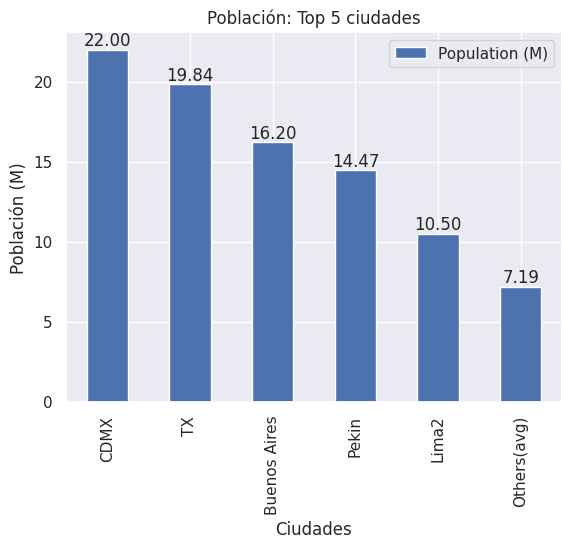

In [174]:
import matplotlib.pyplot as plt #visualización de datos
import seaborn as sns #visualización de datos

%matplotlib inline
sns.set(style='darkgrid')


print("Create a bar chart showing the 'Population' of the top 5 cities (by population).\n")
df_plot = df_exam[['City','Population']].sort_values('Population', ascending = False).head(5)
df_plot.loc[len(df_plot)] = ['Others(avg)',df_exam[['Population']].sort_values('Population', ascending = True).head(5).mean()['Population']]
df_plot['Population (M)'] = round(df_plot['Population']/1000000,2)
df_plot = df_plot.drop('Population', axis = 1).set_index('City')

ax = df_plot.plot(kind = 'bar') #, title = ' ', ylabel=''

# Add axis labels and a title
ax.set_xlabel("Ciudades")
ax.set_ylabel("Población (M)")
ax.set_title("Población: Top 5 ciudades")
ax.bar_label(ax.containers[0], fmt='%.2f')


Create a pie chart showing the 'Surface Area' distribution by 'Country'.


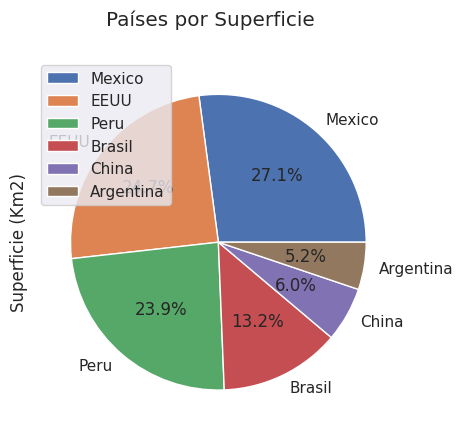

In [196]:
print("Create a pie chart showing the 'Surface Area' distribution by 'Country'.")
df_plot = df_exam[['Surface Area(km2)','Country']].set_index('Country').groupby('Country').sum().sort_values('Surface Area(km2)', ascending = False)

ax = df_plot.plot(kind = 'pie', subplots=True,
                  title="Países por Superficie",
                  ylabel="Superficie (Km2)",
                  autopct='%1.1f%%') # Added autopct to display values
